# SentinelFlow: CNN-GRU-Based Intrusion Detection Using Time-Windowed and FFT-Enhanced NetFlow Features

**Notebook:** Memory-Safe Full Pipeline  
**Purpose:** Use a large NetFlow dataset without crashing memory, then build a Deep Learning intrusion detection pipeline.

This notebook is designed for large CSV datasets such as NetFlow V3 datasets with millions of rows. It avoids loading and sorting the full dataset unless you explicitly configure it to do so.

## Main pipeline

1. Locate and inspect the NetFlow CSV dataset.
2. Load a memory-safe working sample.
3. Clean and prepare labels.
4. Perform Exploratory Data Analysis, or EDA.
5. Train baseline Machine Learning, or ML, models.
6. Create time-windowed NetFlow sequences.
7. Extract Fast Fourier Transform, or FFT, features.
8. Train Gated Recurrent Unit, Long Short-Term Memory, CNN-GRU, and CNN-GRU plus FFT models.
9. Compare model results and discuss limitations.

## Important

Place your downloaded dataset in one of these locations:

```text
./data/raw/NetFlow_v3_Features.csv
./NetFlow_v3_Features.csv
../data/raw/NetFlow_v3_Features.csv
```

If your downloaded file has a different name, either rename it to `NetFlow_v3_Features.csv` or add its filename to the `DATASET_CANDIDATES` list in the configuration cell.

In [1]:
# ============================================================
# SentinelFlow Full Pipeline Notebook
# Memory-Safe Version
# ============================================================

print("SentinelFlow Memory-Safe Full Pipeline")
print("CNN-GRU-Based Intrusion Detection Using Time-Windowed and FFT-Enhanced NetFlow Features")

SentinelFlow Memory-Safe Full Pipeline
CNN-GRU-Based Intrusion Detection Using Time-Windowed and FFT-Enhanced NetFlow Features


## 1. Import Libraries

This notebook avoids special display packages. It uses common Python libraries only.

If TensorFlow is not installed, the notebook will still run the data preparation and baseline ML sections, then tell you how to install TensorFlow for the Deep Learning section.

In [2]:
import os
import gc
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, HTML

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    HAS_TENSORFLOW = True
    print("TensorFlow detected:", tf.__version__)
except Exception as e:
    HAS_TENSORFLOW = False
    print("TensorFlow is not available yet.")
    print("Deep Learning cells will be skipped until TensorFlow is installed.")
    print("Install with: pip install tensorflow")

print("Libraries imported successfully.")

TensorFlow detected: 2.18.0
Libraries imported successfully.


## 2. Configuration

This is the most important setup section. The defaults are intentionally memory-safe.

For a large dataset such as 19 million rows, keep `MAX_ROWS_FOR_NOTEBOOK` between `300_000` and `500_000` first.

In [3]:
# ============================================================
# Configuration
# ============================================================

PROJECT_TITLE = "SentinelFlow"
RANDOM_STATE = 42

# Dataset filenames and paths to search.
DATASET_CANDIDATES = [
    "data/raw/NetFlow_v3_Features.csv",
    "NetFlow_v3_Features.csv",
    "../data/raw/NetFlow_v3_Features.csv",
    "data/raw/NF-UNSW-NB15-v3.csv",
    "NF-UNSW-NB15-v3.csv",
    "../data/raw/NF-UNSW-NB15-v3.csv",
]

# Memory-safe loading settings.
# Recommended first run: 300_000 rows.
MAX_ROWS_FOR_NOTEBOOK = 300_000
CHUNK_SIZE = 250_000

# Loading strategy options:
# "first_n"       = fastest and safest; loads only the first MAX_ROWS_FOR_NOTEBOOK rows.
# "chunked_random" = scans the file in chunks and samples from across the file; slower but more representative.
LOAD_STRATEGY = "chunked_random"

# Set these manually if automatic detection chooses the wrong columns.
MANUAL_TARGET_COL = "Attack"   # Example: "Attack" or "Label"
MANUAL_TIMESTAMP_COL = None    # Example: "Timestamp"

# Modeling settings.
BASELINE_MAX_ROWS = 100_000
WINDOW_SIZE = 30
WINDOW_STRIDE = 30
WINDOW_LABEL_MODE = "any_attack"  # Options: "any_attack" or "majority"
MAX_WINDOWS_FOR_DEEP_LEARNING = 12_000
FFT_BINS = 8
FFT_MAX_FEATURES = 12

# Deep Learning training settings.
EPOCHS = 15
BATCH_SIZE = 64
VALIDATION_SPLIT = 0.15
TEST_SIZE = 0.20

print("Configuration loaded.")
print(f"MAX_ROWS_FOR_NOTEBOOK: {MAX_ROWS_FOR_NOTEBOOK:,}")
print(f"LOAD_STRATEGY: {LOAD_STRATEGY}")
print(f"WINDOW_SIZE: {WINDOW_SIZE}")
print(f"WINDOW_STRIDE: {WINDOW_STRIDE}")

Configuration loaded.
MAX_ROWS_FOR_NOTEBOOK: 300,000
LOAD_STRATEGY: chunked_random
WINDOW_SIZE: 30
WINDOW_STRIDE: 30


## 3. Helper Functions

These functions keep the notebook readable and prevent common memory problems.

In [4]:
# ============================================================
# Helper Functions
# ============================================================

def show_card(title, body, color="#2563eb"):
    html = f"""
    <div style="border-left: 6px solid {color}; padding: 14px 18px; margin: 12px 0; 
                background: #f8fafc; border-radius: 12px; font-family: Arial, sans-serif;">
        <div style="font-weight: 800; font-size: 18px; color: #0f172a; margin-bottom: 6px;">{title}</div>
        <div style="font-size: 14px; color: #334155; line-height: 1.5;">{body}</div>
    </div>
    """
    display(HTML(html))


def find_dataset_path(candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    return None


def file_size_mb(path):
    return path.stat().st_size / (1024 ** 2)


def memory_usage_mb(df):
    return df.memory_usage(deep=True).sum() / (1024 ** 2)


def optimize_dataframe_memory(df):
    """Downcast numerical columns to reduce RAM usage."""
    df = df.copy()
    for col in df.select_dtypes(include=["int64", "int32"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")
    for col in df.select_dtypes(include=["float64", "float32"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="float")
    return df


def detect_target_column(columns):
    if MANUAL_TARGET_COL is not None:
        return MANUAL_TARGET_COL

    exact_candidates = [
        "Label", "label", "Attack", "attack", "Class", "class",
        "Category", "category", "target", "Target", "Type", "type",
        "is_attack", "IsAttack", "BENIGN", "Malicious"
    ]
    for candidate in exact_candidates:
        if candidate in columns:
            return candidate

    keyword_candidates = []
    keywords = ["label", "attack", "class", "category", "target"]
    for col in columns:
        if any(key in col.lower() for key in keywords):
            keyword_candidates.append(col)

    return keyword_candidates[0] if keyword_candidates else None


def choose_target_column(df):
    """Choose the most informative target column from the preview dataframe."""
    if MANUAL_TARGET_COL is not None:
        return MANUAL_TARGET_COL

    columns = list(df.columns)
    initial = detect_target_column(columns)

    candidate_cols = []
    for col in columns:
        lower_col = col.lower()
        if col == initial or any(key in lower_col for key in ["label", "attack", "class", "category", "target", "malicious", "benign"]):
            candidate_cols.append(col)

    # Preserve order while removing duplicates.
    candidate_cols = list(dict.fromkeys(candidate_cols))
    if not candidate_cols:
        return initial

    def score_column(series, col_name):
        non_null = series.dropna()
        if non_null.empty:
            return (-10, col_name)

        unique_count = non_null.nunique(dropna=True)
        normalized = non_null.astype(str).str.strip().str.lower()
        keyword_hits = normalized.str.contains("attack|malicious|benign|normal|dos|ddos|bot|brute|web|infiltration").sum()
        binary_like = unique_count == 2
        looks_constant = unique_count <= 1
        name_bonus = 2 if any(key in col_name.lower() for key in ["attack", "class", "category", "target"]) else 0

        score = 0
        score += 5 if binary_like else 0
        score += 3 if unique_count > 1 else -6
        score += 2 if keyword_hits > 0 else 0
        score += name_bonus
        score += -4 if looks_constant else 0

        return (score, col_name)

    scored = sorted(((score_column(df[col], col), col) for col in candidate_cols), reverse=True)
    return scored[0][1] if scored else initial


def detect_timestamp_column(columns):
    if MANUAL_TIMESTAMP_COL is not None:
        return MANUAL_TIMESTAMP_COL

    keywords = ["timestamp", "time", "date", "datetime", "start", "end"]
    candidates = []
    for col in columns:
        lowered = col.lower()
        if any(key in lowered for key in keywords):
            candidates.append(col)

    # Avoid selecting duration columns as timestamps unless no better option exists.
    clean_candidates = [c for c in candidates if "duration" not in c.lower()]
    if clean_candidates:
        return clean_candidates[0]
    return None


def make_binary_label(series):
    """Convert common NetFlow target formats into 0 = normal, 1 = attack."""
    s = series.copy()

    # Numeric labels such as 0/1.
    if pd.api.types.is_numeric_dtype(s):
        unique_values = set(pd.Series(s.dropna().unique()).astype(float).tolist())
        if unique_values.issubset({0.0, 1.0}):
            return s.fillna(0).astype(int)
        # If numeric but not 0/1, assume 0 is normal and nonzero is attack.
        return (s.fillna(0).astype(float) != 0).astype(int)

    normal_keywords = {
        "normal", "benign", "legitimate", "none", "no", "0", "false", "clean"
    }
    return s.astype(str).str.strip().str.lower().apply(lambda x: 0 if x in normal_keywords else 1).astype(int)


def safe_train_test_split(X, y, test_size=0.2, random_state=42):
    try:
        return train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
    except Exception:
        return train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=None
        )


def plot_label_distribution(series, title):
    counts = series.value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar([str(i) for i in counts.index], counts.values)
    ax.set_title(title)
    ax.set_xlabel("Class")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)
    plt.tight_layout()
    plt.show()

print("Helper functions ready.")

Helper functions ready.


## 4. Locate and Inspect the Dataset

This cell checks whether the dataset exists and inspects the header without loading the full CSV into memory.

In [5]:
# ============================================================
# Locate Dataset
# ============================================================

DATA_PATH = find_dataset_path(DATASET_CANDIDATES)

if DATA_PATH is None:
    show_card(
        "Dataset Not Found",
        "Place your CSV file inside <b>data/raw/</b> and rename it to <b>NetFlow_v3_Features.csv</b>, then rerun this notebook.",
        "#dc2626"
    )
    raise FileNotFoundError("Dataset file was not found in the configured search paths.")

show_card(
    "Dataset Found",
    f"Using dataset: <b>{DATA_PATH}</b><br>File size: <b>{file_size_mb(DATA_PATH):,.2f} MB</b>",
    "#16a34a"
)

# Read only a few rows to inspect columns.
df_preview = pd.read_csv(DATA_PATH, nrows=5)

print("Preview shape:", df_preview.shape)
display(df_preview.head())

print("Columns detected:")
for i, col in enumerate(df_preview.columns, start=1):
    print(f"{i:02d}. {col}")

Preview shape: (5, 55)


,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1518611287705,1518611287705,172.31.0.2,53,172.31.66.58,63593,17,5,156,1,0,0,0,0,0,1,0,0,0,0,156,156,0,156,0,1,0,0,0,0,1248000,0,0,1,0,0,0,0,0,0,0,45856,1,60,0,0,0,0,0,0,0,0,0,0,Benign
1,1518611287743,1518611290747,172.31.66.58,56163,239.255.255.250,1900,17,12,805,5,0,0,0,0,0,3003,3003,0,1,1,161,161,0,161,0,0,0,0,0,0,2143,0,0,5,0,0,0,0,0,0,0,0,0,0,0,0,2793,750,1182,0,0,0,0,0,Benign
2,1518611288143,1518611300202,172.31.66.46,62388,239.255.255.250,1900,17,12,1288,8,0,0,0,0,0,12058,12058,0,1,1,161,161,0,161,0,0,0,0,0,0,854,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0,3016,1722,1436,0,0,0,0,0,Benign
3,1518611288165,1518611336194,0.0.0.0,546,0.0.0.0,547,17,103,393,3,0,0,0,0,0,48029,48029,0,1,1,131,131,0,131,0,0,0,0,0,0,65,0,0,3,0,0,0,0,0,0,0,0,0,0,0,16014,32014,24014,8000,0,0,0,0,0,Benign
4,1518611288175,1518611288176,172.31.66.46,49187,169.254.169.254,80,6,7,373,5,700,5,27,27,27,1,0,0,128,128,528,40,40,528,700,373,0,0,0,0,1492000,2800000,8,1,0,1,0,8192,17922,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign


Columns detected:
01. FLOW_START_MILLISECONDS
02. FLOW_END_MILLISECONDS
03. IPV4_SRC_ADDR
04. L4_SRC_PORT
05. IPV4_DST_ADDR
06. L4_DST_PORT
07. PROTOCOL
08. L7_PROTO
09. IN_BYTES
10. IN_PKTS
11. OUT_BYTES
12. OUT_PKTS
13. TCP_FLAGS
14. CLIENT_TCP_FLAGS
15. SERVER_TCP_FLAGS
16. FLOW_DURATION_MILLISECONDS
17. DURATION_IN
18. DURATION_OUT
19. MIN_TTL
20. MAX_TTL
21. LONGEST_FLOW_PKT
22. SHORTEST_FLOW_PKT
23. MIN_IP_PKT_LEN
24. MAX_IP_PKT_LEN
25. SRC_TO_DST_SECOND_BYTES
26. DST_TO_SRC_SECOND_BYTES
27. RETRANSMITTED_IN_BYTES
28. RETRANSMITTED_IN_PKTS
29. RETRANSMITTED_OUT_BYTES
30. RETRANSMITTED_OUT_PKTS
31. SRC_TO_DST_AVG_THROUGHPUT
32. DST_TO_SRC_AVG_THROUGHPUT
33. NUM_PKTS_UP_TO_128_BYTES
34. NUM_PKTS_128_TO_256_BYTES
35. NUM_PKTS_256_TO_512_BYTES
36. NUM_PKTS_512_TO_1024_BYTES
37. NUM_PKTS_1024_TO_1514_BYTES
38. TCP_WIN_MAX_IN
39. TCP_WIN_MAX_OUT
40. ICMP_TYPE
41. ICMP_IPV4_TYPE
42. DNS_QUERY_ID
43. DNS_QUERY_TYPE
44. DNS_TTL_ANSWER
45. FTP_COMMAND_RET_CODE
46. SRC_TO_DST_IAT_MIN
47. SR

## 5. Detect Target and Timestamp Columns

The target column is needed for normal-vs-attack labeling. A timestamp column is useful for chronological sorting, but the notebook can still proceed without one.

In [6]:
# ============================================================
# Detect Target and Timestamp Columns
# ============================================================

TARGET_COL = choose_target_column(df_preview)
TIMESTAMP_COL = detect_timestamp_column(df_preview.columns)

if TARGET_COL is None:
    show_card(
        "Target Column Not Detected",
        "The notebook could not automatically detect the label column. Set <b>MANUAL_TARGET_COL</b> in the configuration cell, then rerun.",
        "#dc2626"
    )
    raise ValueError("Target column could not be detected.")

show_card(
    "Target Column Detected",
    f"Selected target column: <b>{TARGET_COL}</b>",
    "#2563eb"
)

if TIMESTAMP_COL is None:
    show_card(
        "No Timestamp Column Detected",
        "Time-window creation will use dataset row order. This should be stated as a project limitation.",
        "#ca8a04"
    )
else:
    show_card(
        "Timestamp-Like Column Detected",
        f"Selected timestamp column: <b>{TIMESTAMP_COL}</b>. Sorting will be applied only after memory-safe sampling.",
        "#0891b2"
    )

## 6. Memory-Safe Dataset Loading

This is the major fix for the `MemoryError` problem. The notebook does **not** sort all 19 million rows. It first creates a manageable working sample, then performs cleaning and sorting.

In [7]:
# ============================================================
# Memory-Safe Dataset Loading
# ============================================================

required_cols = None  # Keep all columns for now. Feature filtering happens later.

print("Loading strategy:", LOAD_STRATEGY)
print("Maximum rows for notebook:", f"{MAX_ROWS_FOR_NOTEBOOK:,}")

if LOAD_STRATEGY == "first_n":
    df = pd.read_csv(DATA_PATH, nrows=MAX_ROWS_FOR_NOTEBOOK, usecols=required_cols)
    show_card(
        "Memory-Safe First-N Loading Complete",
        f"Loaded the first <b>{len(df):,}</b> rows from the dataset. This is the fastest safe option for notebook development.",
        "#16a34a"
    )

elif LOAD_STRATEGY == "chunked_random":
    sampled_chunks = []
    rng = np.random.default_rng(RANDOM_STATE)
    rows_collected = 0
    sample_per_chunk = max(5_000, MAX_ROWS_FOR_NOTEBOOK // 25)
    chunk_counter = 0

    for chunk in pd.read_csv(DATA_PATH, chunksize=CHUNK_SIZE, usecols=required_cols):
        chunk_counter += 1
        chunk = optimize_dataframe_memory(chunk)
        n_take = min(sample_per_chunk, len(chunk))
        sampled = chunk.sample(n=n_take, random_state=int(rng.integers(0, 1_000_000)))
        sampled_chunks.append(sampled)
        rows_collected += len(sampled)

        print(f"Chunk {chunk_counter}: collected {rows_collected:,} sampled rows")

    df = pd.concat(sampled_chunks, ignore_index=True)
    if len(df) > MAX_ROWS_FOR_NOTEBOOK:
        df = df.sample(n=MAX_ROWS_FOR_NOTEBOOK, random_state=RANDOM_STATE).reset_index(drop=True)

    show_card(
        "Memory-Safe Chunked Random Loading Complete",
        f"Loaded <b>{len(df):,}</b> sampled rows across chunks. This is slower but more representative than first-N loading.",
        "#16a34a"
    )
else:
    raise ValueError("LOAD_STRATEGY must be either 'first_n' or 'chunked_random'.")

print("Raw loaded sample shape:", df.shape)
print(f"Approximate memory usage: {memory_usage_mb(df):,.2f} MB")
display(df.head())

Loading strategy: chunked_random
Maximum rows for notebook: 300,000
Chunk 1: collected 12,000 sampled rows
Chunk 2: collected 24,000 sampled rows
Chunk 3: collected 36,000 sampled rows
Chunk 4: collected 48,000 sampled rows
Chunk 5: collected 60,000 sampled rows
Chunk 6: collected 72,000 sampled rows
Chunk 7: collected 84,000 sampled rows
Chunk 8: collected 96,000 sampled rows
Chunk 9: collected 108,000 sampled rows
Chunk 10: collected 120,000 sampled rows
Chunk 11: collected 132,000 sampled rows
Chunk 12: collected 144,000 sampled rows
Chunk 13: collected 156,000 sampled rows
Chunk 14: collected 168,000 sampled rows
Chunk 15: collected 180,000 sampled rows
Chunk 16: collected 192,000 sampled rows
Chunk 17: collected 204,000 sampled rows
Chunk 18: collected 216,000 sampled rows
Chunk 19: collected 228,000 sampled rows
Chunk 20: collected 240,000 sampled rows
Chunk 21: collected 252,000 sampled rows
Chunk 22: collected 264,000 sampled rows
Chunk 23: collected 276,000 sampled rows
Chunk 

Raw loaded sample shape: (300000, 55)
Approximate memory usage: 106.73 MB


,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack
0,1519825628382,1519825628382,172.31.66.40,49635,172.31.0.2,53,17,5,62,1,94,1,0,0,0,1,0,0,128,128,94,62,62,94,0,0,0,0,0,0,496000,752000,4,0,0,0,0,0,0,0,0,48825,1,60,0,38,38,38,0,0,0,0,0,0,Benign
1,1518708660252,1518708660252,172.31.64.96,59510,172.31.0.2,53,17,5,57,1,129,1,0,0,0,1,0,0,0,0,129,57,57,129,1,0,0,0,0,0,456000,1032000,1,1,0,0,0,0,0,0,0,15522,28,54,0,0,0,0,0,0,0,0,0,0,Benign
2,1519999247431,1519999251379,193.111.198.65,54980,172.31.66.72,3389,6,88,2011,14,2103,9,219,219,26,3947,3947,3947,101,101,1219,40,40,1219,0,0,0,0,0,0,4074,4261,15,5,1,1,1,8192,64000,0,0,0,0,0,0,19,1271,303,352,19,1066,493,351,0,Benign
3,1518729841483,1518729841483,179.100.49.7,44225,172.31.66.42,23,6,77,40,1,0,0,2,2,0,1,0,0,0,0,40,40,0,40,0,0,0,0,0,0,320000,0,1,0,0,0,0,14600,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign
4,1520010486905,1520010486905,5.188.11.111,58687,172.31.66.53,7654,6,0,40,1,0,0,2,2,0,1,0,0,0,0,40,40,0,40,0,0,0,0,0,0,320000,0,1,0,0,0,0,1024,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Benign


## 7. Clean Labels, Optimize Memory, and Sort Safely

The original error happened because the full dataset was sorted and copied. This section works only on the sampled dataset.

In [8]:
# ============================================================
# Clean Labels, Optimize Memory, and Sort Safely
# ============================================================

df_clean = df.copy()

# Remove exact duplicate rows only inside the working sample.
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

# Create binary label.
df_clean["binary_label"] = make_binary_label(df_clean[TARGET_COL])

if df_clean["binary_label"].nunique() < 2:
    raise ValueError(
        f"Selected target column '{TARGET_COL}' produced only one class after binarization. "
        "Set MANUAL_TARGET_COL to the semantic attack label column and rerun from the target-detection step."
    )

# Optimize after label creation.
df_clean = optimize_dataframe_memory(df_clean)
gc.collect()

show_card(
    "Initial Cleaning Complete",
    f"Rows before duplicate removal: <b>{before:,}</b><br>Rows after duplicate removal: <b>{after:,}</b><br>Duplicates removed: <b>{before - after:,}</b>",
    "#2563eb"
)

# Sort only after sampling and memory optimization.
if TIMESTAMP_COL is not None and TIMESTAMP_COL in df_clean.columns:
    parsed_time = pd.to_datetime(df_clean[TIMESTAMP_COL], errors="coerce")
    valid_time_count = parsed_time.notna().sum()

    if valid_time_count > 0:
        df_clean["__parsed_timestamp__"] = parsed_time
        df_clean = df_clean.sort_values("__parsed_timestamp__", kind="mergesort")
        df_clean = df_clean.reset_index(drop=True)
        show_card(
            "Chronological Sorting Applied Safely",
            f"Rows were sorted using <b>{TIMESTAMP_COL}</b> after sampling. Valid parsed timestamps: <b>{valid_time_count:,}</b>",
            "#0891b2"
        )
    else:
        show_card(
            "Timestamp Parsing Skipped",
            "A timestamp-like column was detected, but values could not be parsed properly. Row order will be used instead.",
            "#ca8a04"
        )
else:
    show_card(
        "Row Order Will Be Used",
        "No valid timestamp column was used. Time-window creation will follow the dataset row order.",
        "#ca8a04"
    )

gc.collect()
print("Cleaned dataset shape:", df_clean.shape)
print(f"Approximate memory usage: {memory_usage_mb(df_clean):,.2f} MB")
display(df_clean.head())

Cleaned dataset shape: (299853, 57)
Approximate memory usage: 109.25 MB


,FLOW_START_MILLISECONDS,FLOW_END_MILLISECONDS,IPV4_SRC_ADDR,L4_SRC_PORT,IPV4_DST_ADDR,L4_DST_PORT,PROTOCOL,L7_PROTO,IN_BYTES,IN_PKTS,OUT_BYTES,OUT_PKTS,TCP_FLAGS,CLIENT_TCP_FLAGS,SERVER_TCP_FLAGS,FLOW_DURATION_MILLISECONDS,DURATION_IN,DURATION_OUT,MIN_TTL,MAX_TTL,LONGEST_FLOW_PKT,SHORTEST_FLOW_PKT,MIN_IP_PKT_LEN,MAX_IP_PKT_LEN,SRC_TO_DST_SECOND_BYTES,DST_TO_SRC_SECOND_BYTES,RETRANSMITTED_IN_BYTES,RETRANSMITTED_IN_PKTS,RETRANSMITTED_OUT_BYTES,RETRANSMITTED_OUT_PKTS,SRC_TO_DST_AVG_THROUGHPUT,DST_TO_SRC_AVG_THROUGHPUT,NUM_PKTS_UP_TO_128_BYTES,NUM_PKTS_128_TO_256_BYTES,NUM_PKTS_256_TO_512_BYTES,NUM_PKTS_512_TO_1024_BYTES,NUM_PKTS_1024_TO_1514_BYTES,TCP_WIN_MAX_IN,TCP_WIN_MAX_OUT,ICMP_TYPE,ICMP_IPV4_TYPE,DNS_QUERY_ID,DNS_QUERY_TYPE,DNS_TTL_ANSWER,FTP_COMMAND_RET_CODE,SRC_TO_DST_IAT_MIN,SRC_TO_DST_IAT_MAX,SRC_TO_DST_IAT_AVG,SRC_TO_DST_IAT_STDDEV,DST_TO_SRC_IAT_MIN,DST_TO_SRC_IAT_MAX,DST_TO_SRC_IAT_AVG,DST_TO_SRC_IAT_STDDEV,Label,Attack,binary_label,__parsed_timestamp__
0,1518611293912,1518611367144,172.31.66.99,138,172.31.66.127,138,17,10,2357,11,0,0,0,0,0,73232,73232,0,128,128,232,202,0,232,0,0,0,0,0,0,257,0,0,11,0,0,0,0,0,0,0,0,0,0,0,0,56447,7322,16496,0,0,0,0,0,Benign,0,1970-01-01 00:25:18.611293912
1,1518611295782,1518611295903,172.31.66.58,59482,172.31.0.2,53,17,5,62,1,153,1,0,0,0,121,0,0,0,0,153,62,62,153,1,0,0,0,0,0,4065,10032,1,1,0,0,0,0,0,0,0,39943,1,60,0,0,0,0,0,0,0,0,0,0,Benign,0,1970-01-01 00:25:18.611295782
2,1518611296676,1518611296679,172.31.65.25,49457,172.31.0.2,53,17,5,70,1,183,1,0,0,0,2,0,0,0,0,183,70,70,183,91,35,0,0,0,0,186666,488000,1,1,0,0,0,0,0,0,0,62288,1,33,0,0,0,0,0,0,0,0,0,0,Benign,0,1970-01-01 00:25:18.611296676
3,1518611296818,1518611296818,172.31.66.58,57496,172.31.0.2,53,17,5,89,1,137,1,0,0,0,1,0,0,0,0,137,89,89,137,1,0,0,0,0,0,712000,1096000,1,1,0,0,0,0,0,0,0,58708,1,60,0,0,0,0,0,0,0,0,0,0,Benign,0,1970-01-01 00:25:18.611296818
4,1518611296818,1518611296831,172.31.66.58,62842,172.31.0.2,53,17,5,89,1,176,1,0,0,0,12,0,0,0,0,176,89,89,176,14,7,0,0,0,0,54769,108307,1,1,0,0,0,0,0,0,0,24626,28,60,0,0,0,0,0,0,0,0,0,0,Benign,0,1970-01-01 00:25:18.611296818


## 8. Dataset Summary and Class Distribution

This confirms whether the sampled dataset still contains both normal and attack traffic.

,Item,Value
0,Dataset Path,data\raw\NetFlow_v3_Features.csv
1,Loaded Rows,"299,853"
2,Loaded Columns,57
3,Target Column,Attack
4,Timestamp Column,FLOW_START_MILLISECONDS
5,Normal Samples,"261,183"
6,Attack Samples,"38,670"
7,Approximate Memory Usage MB,109.25


,Count
binary_label,
Normal,261183
Attack,38670


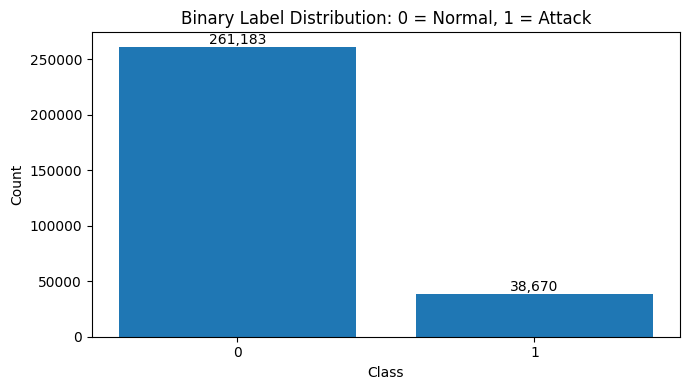

In [9]:
# ============================================================
# Dataset Summary and Class Distribution
# ============================================================

summary = pd.DataFrame({
    "Item": [
        "Dataset Path",
        "Loaded Rows",
        "Loaded Columns",
        "Target Column",
        "Timestamp Column",
        "Normal Samples",
        "Attack Samples",
        "Approximate Memory Usage MB",
    ],
    "Value": [
        str(DATA_PATH),
        f"{len(df_clean):,}",
        f"{df_clean.shape[1]:,}",
        TARGET_COL,
        TIMESTAMP_COL if TIMESTAMP_COL is not None else "None detected",
        f"{(df_clean['binary_label'] == 0).sum():,}",
        f"{(df_clean['binary_label'] == 1).sum():,}",
        f"{memory_usage_mb(df_clean):,.2f}",
    ]
})

display(summary)

label_counts = df_clean["binary_label"].value_counts().rename(index={0: "Normal", 1: "Attack"})
display(label_counts.to_frame("Count"))
plot_label_distribution(df_clean["binary_label"], "Binary Label Distribution: 0 = Normal, 1 = Attack")

## 9. Feature Selection and Numeric Preparation

For the first SentinelFlow implementation, we use numerical NetFlow features. High-cardinality text fields such as IP addresses are excluded to keep the model stable and memory-safe.

In [10]:
# ============================================================
# Feature Selection and Numeric Preparation
# ============================================================

label_like_cols = {
    "Label", "label", "Attack", "attack", "Class", "class",
    "Category", "category", "target", "Target", "Type", "type",
    "is_attack", "IsAttack", "BENIGN", "Malicious"
}
exclude_cols = {TARGET_COL, "binary_label", "__parsed_timestamp__"}
exclude_cols.update(col for col in df_clean.columns if col in label_like_cols)
if TIMESTAMP_COL is not None:
    exclude_cols.add(TIMESTAMP_COL)

# Keep numerical features only for the first pipeline.
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]
leaked_feature_cols = sorted(col for col in feature_cols if col in label_like_cols or col == TARGET_COL)
if leaked_feature_cols:
    raise ValueError(f"Label leakage detected in feature columns: {leaked_feature_cols}")

if len(feature_cols) == 0:
    raise ValueError("No numerical feature columns were found. Check the dataset column types.")

# Replace inf values and fill missing numerical values.
X_df = df_clean[feature_cols].replace([np.inf, -np.inf], np.nan)
X_df = X_df.fillna(X_df.median(numeric_only=True))
y = df_clean["binary_label"].astype(int).values

# Downcast for memory efficiency.
X_df = optimize_dataframe_memory(X_df)

show_card(
    "Numerical Feature Set Prepared",
    f"Using <b>{len(feature_cols)}</b> numerical features for baseline ML and Deep Learning.",
    "#2563eb"
)

excluded_present = sorted(col for col in exclude_cols if col in df_clean.columns)
print("Excluded non-feature columns:")
for col in excluded_present:
    print(f"- {col}")

print("Selected feature columns:")
for i, col in enumerate(feature_cols, start=1):
    print(f"{i:02d}. {col}")

print("Feature matrix shape:", X_df.shape)
print("Target shape:", y.shape)
print(f"Feature memory usage: {memory_usage_mb(X_df):,.2f} MB")

Excluded non-feature columns:
- Attack
- FLOW_START_MILLISECONDS
- Label
- __parsed_timestamp__
- binary_label
Selected feature columns:
01. FLOW_END_MILLISECONDS
02. L4_SRC_PORT
03. L4_DST_PORT
04. PROTOCOL
05. L7_PROTO
06. IN_BYTES
07. IN_PKTS
08. OUT_BYTES
09. OUT_PKTS
10. TCP_FLAGS
11. CLIENT_TCP_FLAGS
12. SERVER_TCP_FLAGS
13. FLOW_DURATION_MILLISECONDS
14. DURATION_IN
15. DURATION_OUT
16. MIN_TTL
17. MAX_TTL
18. LONGEST_FLOW_PKT
19. SHORTEST_FLOW_PKT
20. MIN_IP_PKT_LEN
21. MAX_IP_PKT_LEN
22. SRC_TO_DST_SECOND_BYTES
23. DST_TO_SRC_SECOND_BYTES
24. RETRANSMITTED_IN_BYTES
25. RETRANSMITTED_IN_PKTS
26. RETRANSMITTED_OUT_BYTES
27. RETRANSMITTED_OUT_PKTS
28. SRC_TO_DST_AVG_THROUGHPUT
29. DST_TO_SRC_AVG_THROUGHPUT
30. NUM_PKTS_UP_TO_128_BYTES
31. NUM_PKTS_128_TO_256_BYTES
32. NUM_PKTS_256_TO_512_BYTES
33. NUM_PKTS_512_TO_1024_BYTES
34. NUM_PKTS_1024_TO_1514_BYTES
35. TCP_WIN_MAX_IN
36. TCP_WIN_MAX_OUT
37. ICMP_TYPE
38. ICMP_IPV4_TYPE
39. DNS_QUERY_ID
40. DNS_QUERY_TYPE
41. DNS_TTL_ANSWER

## 10. Exploratory Data Analysis

This section gives a quick look at selected numerical feature distributions and correlations.

EDA features shown: ['FLOW_END_MILLISECONDS', 'L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'IN_BYTES']


,count,mean,std,min,25%,50%,75%,max
FLOW_END_MILLISECONDS,299853.0,1.519314e+12,4.699890e+08,1.518611e+12,1.518805e+12,1.519249e+12,1.519838e+12,1.520021e+12
L4_SRC_PORT,299853.0,5.003205e+04,1.556482e+04,0.000000e+00,5.024100e+04,5.324300e+04,5.877000e+04,6.553500e+04
L4_DST_PORT,299853.0,2.575820e+03,8.335812e+03,0.000000e+00,5.300000e+01,8.000000e+01,4.450000e+02,6.551600e+04
PROTOCOL,299853.0,1.023128e+01,5.554885e+00,1.000000e+00,6.000000e+00,6.000000e+00,1.700000e+01,5.800000e+01
L7_PROTO,299853.0,3.849416e+01,4.347780e+01,0.000000e+00,5.000000e+00,7.000000e+00,8.800000e+01,3.940000e+02
IN_BYTES,299853.0,2.410010e+03,1.134786e+05,2.800000e+01,6.700000e+01,1.510000e+02,1.126000e+03,1.060938e+07


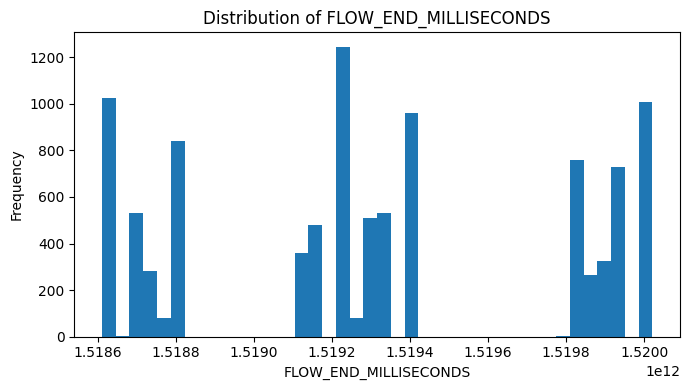

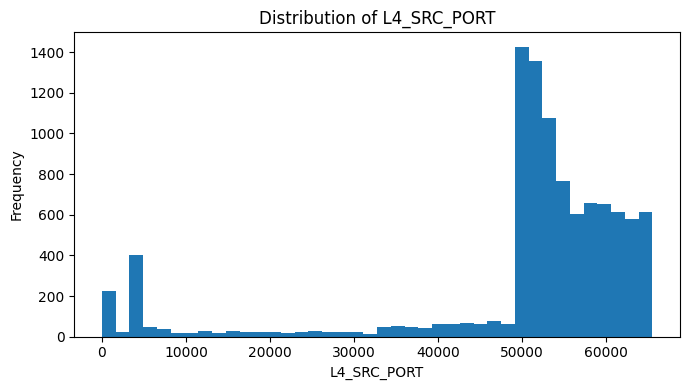

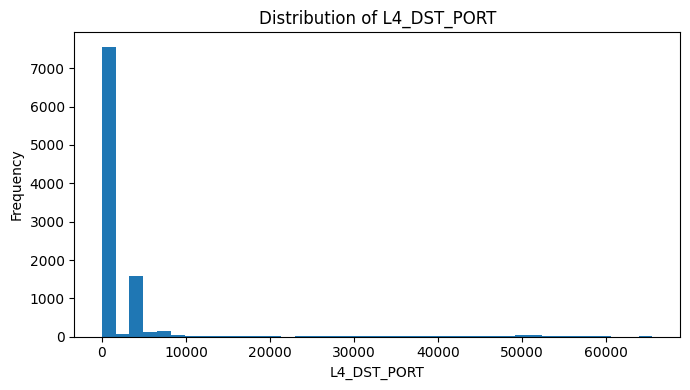

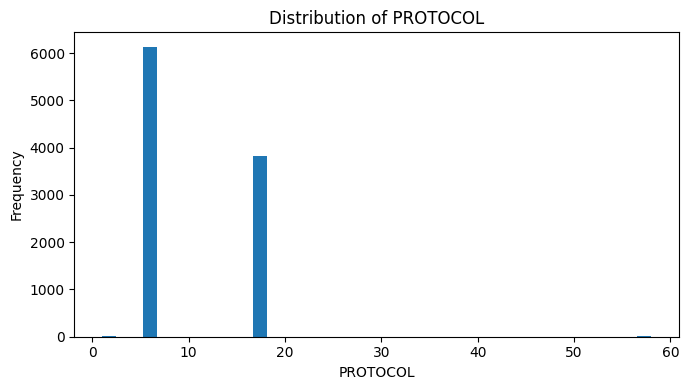

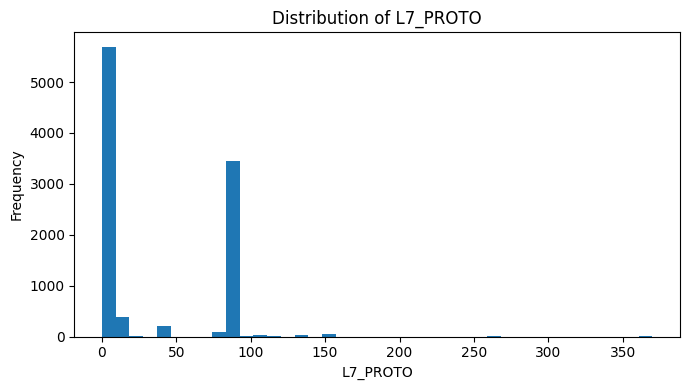

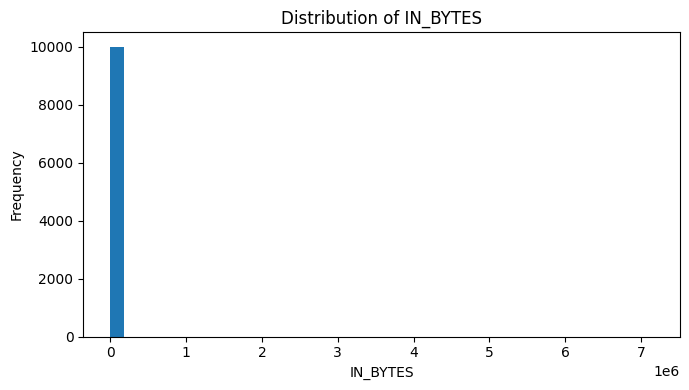

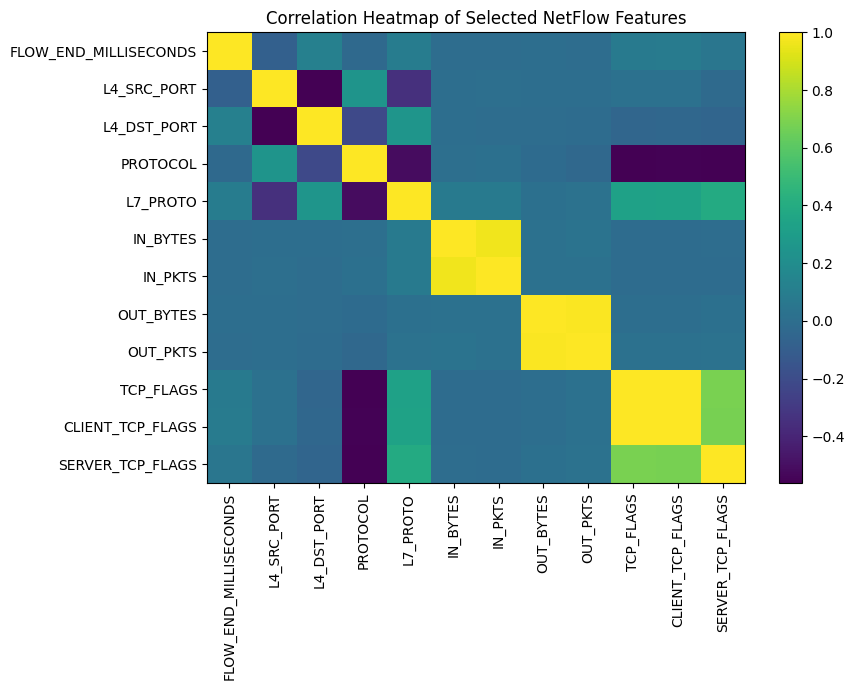

In [11]:
# ============================================================
# EDA: Feature Distributions and Correlations
# ============================================================

# Choose a small set of features for visualization.
eda_features = feature_cols[:min(6, len(feature_cols))]

print("EDA features shown:", eda_features)

display(X_df[eda_features].describe().T)

for col in eda_features:
    fig, ax = plt.subplots(figsize=(7, 4))
    sample_values = X_df[col].sample(n=min(10_000, len(X_df)), random_state=RANDOM_STATE)
    ax.hist(sample_values, bins=40)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()

# Correlation heatmap using matplotlib only.
corr_features = feature_cols[:min(12, len(feature_cols))]
corr = X_df[corr_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr_features)))
ax.set_yticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=90)
ax.set_yticklabels(corr_features)
ax.set_title("Correlation Heatmap of Selected NetFlow Features")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 11. Baseline Machine Learning Models

The baseline models answer this question:

> How well can ordinary row-level ML perform before we use time-windowed Deep Learning?

This is important because SentinelFlow needs comparison models.

Baseline class distribution:


,Count
Normal,87104
Attack,12896


Training baseline model: Logistic Regression
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.99     17421
      Attack       0.94      0.86      0.90      2579

    accuracy                           0.97     20000
   macro avg       0.96      0.93      0.94     20000
weighted avg       0.97      0.97      0.97     20000



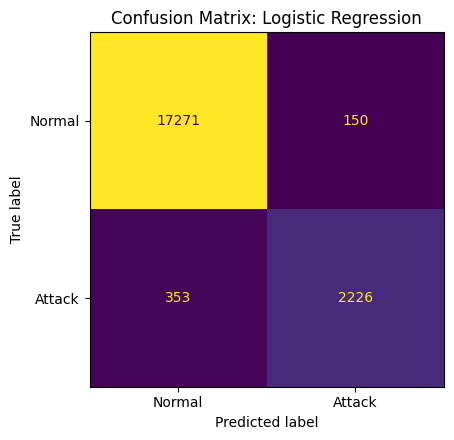

Training baseline model: Random Forest
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     17421
      Attack       1.00      0.95      0.97      2579

    accuracy                           0.99     20000
   macro avg       0.99      0.97      0.98     20000
weighted avg       0.99      0.99      0.99     20000



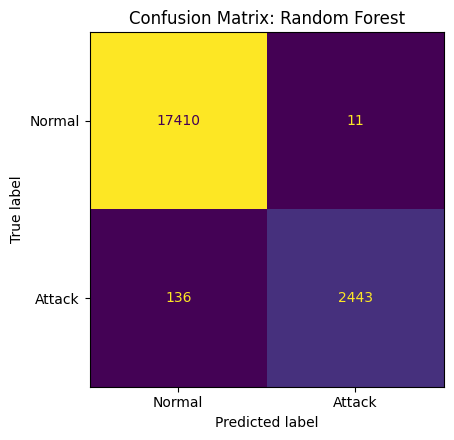

,Model,Input Type,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,Row-level NetFlow features,0.97485,0.936869,0.863125,0.898486,0.969023
1,Random Forest,Row-level NetFlow features,0.99265,0.995518,0.947266,0.970793,0.996445


In [12]:
# ============================================================
# Baseline ML Models
# ============================================================

# Limit baseline rows for speed and memory safety while preserving class balance.
if len(X_df) > BASELINE_MAX_ROWS:
    all_indices = np.arange(len(X_df))
    try:
        baseline_indices, _ = train_test_split(
            all_indices,
            train_size=BASELINE_MAX_ROWS,
            random_state=RANDOM_STATE,
            stratify=y,
        )
    except ValueError:
        baseline_indices = pd.Series(all_indices).sample(
            n=BASELINE_MAX_ROWS, random_state=RANDOM_STATE
        ).values
    X_base = X_df.iloc[baseline_indices].copy()
    y_base = y[baseline_indices]
else:
    X_base = X_df.copy()
    y_base = y.copy()

baseline_class_counts = pd.Series(y_base).value_counts().sort_index()
print("Baseline class distribution:")
display(baseline_class_counts.rename(index={0: "Normal", 1: "Attack"}).to_frame("Count"))

if len(baseline_class_counts) < 2:
    raise ValueError(
        "The baseline sample contains only one class. Confirm MANUAL_TARGET_COL, use LOAD_STRATEGY='chunked_random', "
        "or increase MAX_ROWS_FOR_NOTEBOOK so both normal and attack rows are loaded."
    )

scaler_base = StandardScaler()
X_base_scaled = scaler_base.fit_transform(X_base).astype(np.float32)

X_train_base, X_test_base, y_train_base, y_test_base = safe_train_test_split(
    X_base_scaled, y_base, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

baseline_results = []

models = {
    "Logistic Regression": LogisticRegression(max_iter=500, n_jobs=-1),
    "Random Forest": RandomForestClassifier(
        n_estimators=80,
        max_depth=18,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )
}

for name, model in models.items():
    print(f"Training baseline model: {name}")
    model.fit(X_train_base, y_train_base)
    y_pred = model.predict(X_test_base)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_base)[:, 1]
    else:
        y_score = y_pred

    try:
        auc = roc_auc_score(y_test_base, y_score)
    except Exception:
        auc = np.nan

    result = {
        "Model": name,
        "Input Type": "Row-level NetFlow features",
        "Accuracy": accuracy_score(y_test_base, y_pred),
        "Precision": precision_score(y_test_base, y_pred, zero_division=0),
        "Recall": recall_score(y_test_base, y_pred, zero_division=0),
        "F1-score": f1_score(y_test_base, y_pred, zero_division=0),
        "ROC-AUC": auc,
    }
    baseline_results.append(result)

    print(classification_report(y_test_base, y_pred, target_names=["Normal", "Attack"], zero_division=0))

    cm = confusion_matrix(y_test_base, y_pred)
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Attack"])
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()

baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df)

## 12. Time-Window Sequence Creation

This is the key Deep Learning transformation.

Instead of using one row as one sample, SentinelFlow uses multiple consecutive NetFlow rows as one behavioral window.

Example:

```text
Rows 1 to 30   → Window 1
Rows 31 to 60  → Window 2
Rows 61 to 90  → Window 3
```

The default label rule is `any_attack`, meaning a window is considered malicious if at least one flow inside it is labeled as attack.

X_seq shape: (9995, 30, 50)
y_seq shape: (9995,)
Window class distribution:


,Count
Normal Window,6499
Attack Window,3496


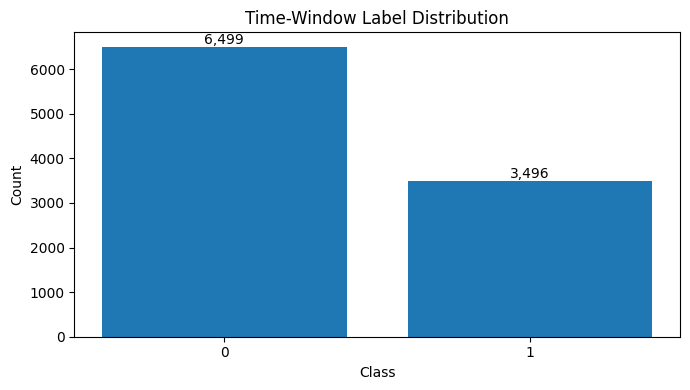

In [13]:
# ============================================================
# Time-Window Sequence Creation
# ============================================================

# Scale the full working sample for sequence models.
scaler_sequence = StandardScaler()
X_scaled = scaler_sequence.fit_transform(X_df).astype(np.float32)
y_sequence_source = y.astype(np.int8)


def create_windows(X, y, window_size=30, stride=30, label_mode="any_attack"):
    X_windows = []
    y_windows = []

    n = len(X)
    for start in range(0, n - window_size + 1, stride):
        end = start + window_size
        x_win = X[start:end]
        y_win = y[start:end]

        if label_mode == "any_attack":
            label = 1 if np.any(y_win == 1) else 0
        elif label_mode == "majority":
            label = int(np.round(np.mean(y_win)))
        else:
            raise ValueError("label_mode must be 'any_attack' or 'majority'.")

        X_windows.append(x_win)
        y_windows.append(label)

    return np.asarray(X_windows, dtype=np.float32), np.asarray(y_windows, dtype=np.int8)

X_seq, y_seq = create_windows(
    X_scaled,
    y_sequence_source,
    window_size=WINDOW_SIZE,
    stride=WINDOW_STRIDE,
    label_mode=WINDOW_LABEL_MODE,
)

# Limit number of windows for memory-safe Deep Learning training.
if len(X_seq) > MAX_WINDOWS_FOR_DEEP_LEARNING:
    window_indices = pd.Series(np.arange(len(X_seq))).sample(
        n=MAX_WINDOWS_FOR_DEEP_LEARNING,
        random_state=RANDOM_STATE
    ).values
    X_seq = X_seq[window_indices]
    y_seq = y_seq[window_indices]

show_card(
    "Time-Window Sequences Created",
    f"Sequence shape: <b>{X_seq.shape}</b><br>Window label mode: <b>{WINDOW_LABEL_MODE}</b>",
    "#7c3aed"
)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)
print("Window class distribution:")
display(pd.Series(y_seq).value_counts().rename(index={0: "Normal Window", 1: "Attack Window"}).to_frame("Count"))
plot_label_distribution(pd.Series(y_seq), "Time-Window Label Distribution")

## 13. FFT Feature Extraction

FFT means **Fast Fourier Transform**. In SentinelFlow, FFT is used to capture burst-like, repeated, or frequency-domain traffic patterns inside each time window.

To keep the model memory-safe, FFT is applied only to the most variable selected features.

In [14]:
# ============================================================
# FFT Feature Extraction
# ============================================================

# Select features with highest variance after scaling.
feature_variance = np.var(X_scaled, axis=0)
fft_feature_indices = np.argsort(feature_variance)[-min(FFT_MAX_FEATURES, len(feature_cols)):]
fft_feature_names = [feature_cols[i] for i in fft_feature_indices]

print("Features selected for FFT:")
for i, name in enumerate(fft_feature_names, start=1):
    print(f"{i:02d}. {name}")


def extract_fft_features(X_windows, selected_indices, fft_bins=8):
    fft_vectors = []

    for window in X_windows:
        selected = window[:, selected_indices]
        spectrum = np.abs(np.fft.rfft(selected, axis=0))

        # Skip the zero-frequency component when possible, then keep early bins.
        if spectrum.shape[0] > 1:
            spectrum = spectrum[1:]

        kept = spectrum[:fft_bins]

        # Pad if the window is too short for the requested number of bins.
        if kept.shape[0] < fft_bins:
            pad_rows = fft_bins - kept.shape[0]
            kept = np.pad(kept, ((0, pad_rows), (0, 0)), mode="constant")

        fft_vectors.append(kept.flatten())

    return np.asarray(fft_vectors, dtype=np.float32)

X_fft = extract_fft_features(X_seq, fft_feature_indices, fft_bins=FFT_BINS)

# Scale FFT vectors separately.
fft_scaler = StandardScaler()
X_fft = fft_scaler.fit_transform(X_fft).astype(np.float32)

show_card(
    "FFT Features Extracted",
    f"FFT feature matrix shape: <b>{X_fft.shape}</b><br>FFT bins: <b>{FFT_BINS}</b><br>Features used for FFT: <b>{len(fft_feature_indices)}</b>",
    "#9333ea"
)

print("X_fft shape:", X_fft.shape)
display(pd.DataFrame(X_fft[:5]).head())

Features selected for FFT:
01. DURATION_IN
02. DURATION_OUT
03. L7_PROTO
04. MIN_IP_PKT_LEN
05. FLOW_END_MILLISECONDS
06. RETRANSMITTED_OUT_PKTS
07. RETRANSMITTED_IN_PKTS
08. SRC_TO_DST_IAT_MAX
09. DST_TO_SRC_IAT_MIN
10. NUM_PKTS_UP_TO_128_BYTES
11. NUM_PKTS_256_TO_512_BYTES
12. DNS_QUERY_TYPE


X_fft shape: (9995, 96)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95
0,-0.051527,0.094267,-0.499110,-1.129163,-0.021492,-0.177432,-0.379094,0.852056,-0.518931,-0.058228,-0.035172,-0.327292,0.084790,0.741268,0.255647,-0.397204,-0.027104,-0.175912,-0.379696,-0.201900,-0.515536,-0.056004,0.118501,0.029503,-0.311752,-1.050472,-0.467003,0.619987,-0.024162,-0.175256,-0.371178,0.627962,-0.513537,-0.061974,-0.403984,0.364013,-0.249161,-1.018195,0.354592,-0.229488,-0.023294,-0.175546,-0.363388,0.100827,-0.516756,-0.058032,-0.313055,0.771912,0.929673,0.190710,-0.220964,0.740460,-0.012019,-0.175357,-0.358907,1.560568,-0.510803,-0.056410,-0.084196,-0.299179,0.080803,0.459486,-1.180939,0.482864,-0.013839,-0.176609,-0.363710,0.725173,-0.515636,-0.055764,0.003312,-0.352875,0.375382,1.132009,-1.117536,-1.183141,-0.011913,-0.175745,-0.360582,0.390862,-0.516847,-0.057124,-0.012205,0.662403,1.835055,1.106706,-1.020106,-0.003679,0.012805,-0.173870,-0.365398,2.734471,-0.514163,-0.061021,-0.007388,-0.008489
1,1.968791,1.988147,-0.990755,-1.123341,-0.032599,-0.177432,0.303695,1.722344,2.546866,-0.055440,-0.084966,-0.715172,-1.109018,-1.086374,0.650730,0.591430,-0.019406,-0.175912,0.311280,-0.350513,2.547528,-0.060833,-0.461795,-0.596803,0.845824,0.876643,0.776074,1.479106,-0.022388,-0.175256,0.328591,1.524922,2.519706,-0.057219,-0.104280,0.590736,1.807122,1.834713,-0.220462,-0.413703,-0.005936,-0.175546,0.348948,1.972468,2.562610,-0.057737,-0.164633,-0.447263,0.639786,0.672696,0.514060,-0.924902,-0.008065,-0.175357,0.348949,0.126925,2.511179,-0.055256,-0.178697,-0.342959,-1.029986,-1.008007,0.287730,0.429512,-0.025755,-0.176609,0.354748,-0.837653,2.559222,-0.060598,-0.138419,0.361548,-1.310939,-1.286444,-0.160971,0.291227,-0.035921,-0.175745,0.344111,0.054275,2.576852,-0.059187,-0.393006,-0.143883,-1.125065,-1.093131,0.371132,-0.599738,-0.047418,-0.173870,0.340007,-0.412613,2.570749,-0.061269,-0.415308,-0.093020
2,-0.938453,-1.134969,-0.989265,-1.166369,-0.033127,0.225095,0.314286,0.196810,-0.510541,-0.060772,-0.294549,-0.379759,-0.032364,-0.135347,-0.329338,-0.144363,-0.026750,0.226822,0.770227,0.483847,-0.508837,-0.062054,-0.191481,0.002518,0.556575,0.766841,0.024816,-0.661563,-0.011486,0.228064,1.210833,-0.232667,-0.506830,-0.056282,-0.142486,0.416154,3.076954,2.938963,0.480534,-0.441677,0.013249,0.228050,2.101398,3.365582,-0.508327,-0.053276,-0.380823,0.377740,1.867494,2.020821,0.247188,-1.179201,0.002182,0.228122,0.025855,1.364503,-0.501697,-0.051118,0.144639,0.033402,0.832406,0.532830,1.376831,0.522408,-0.004673,0.227470,0.194745,0.485050,-0.507255,-0.056267,-0.105464,0.743337,0.946477,0.621110,2.049664,0.721882,-0.007543,0.228917,1.726263,-0.068680,-0.510023,-0.052400,-0.476572,0.518058,0.088001,-0.105312,1.205798,0.825321,-0.020985,0.230844,0.856907,2.221783,-0.507399,-0.054355,0.167226,0.207950
3,-1.249197,-1.038609,0.266620,-0.883870,-0.036084,0.090920,-0.649421,-1.378060,-0.252151,-0.061250,-0.176790,0.139089,-1.311202,-1.182303,0.190878,-0.989876,-0.034448,0.092578,-0.790275,-1.281872,-0.261205,-0.061783,-0.021019,-0.227665,-0.598478,-0.896554,0.070926,0.834255,-0.023307,0.093624,-0.593324,-0.638691,-0.242902,-0.059121,-0.081699,1.067142,-1.124301,-0.951294,-0.305345,-0.670297,-0.033653,0.093518,-0.515778,-1.227511,-0.237942,-0.060650,-0.125724,-0.003587,-1.151384,-1.127431,-0.339352,-0.322588,-0.033201,0.093629,-0.697892,-1.110089,-0.250658,-0.059449,-0.269366,-0.326237,-0.762920,-1.065819,-0.076753,1.066693,-0.030369,0.092777,-0.759628,-0.896164,-0.255738,-0.059873,-0.115862,1.104874,-1.032219,-0.951174,-0.441186,-0.816915,-0.037328,0.094030,-0.539870,-1.086180,-0.240260,-0.060579,-0.359232,0.777789,-1.035270,-0.999252,-0.689735,-0.771735,-0.046320,0.095939,-0.544867,-1.023032,-0.237069,-0.062340,-0.352589,0.249895
4,0.481856,0.5

## 14. Train-Test Split for Deep Learning

The sequence input and FFT input must be split using the same indices so their samples stay aligned.

In [15]:
# ============================================================
# Train-Test Split for Deep Learning
# ============================================================

indices = np.arange(len(X_seq))
train_idx, test_idx, y_train_seq, y_test_seq = safe_train_test_split(
    indices, y_seq, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

X_train_seq = X_seq[train_idx]
X_test_seq = X_seq[test_idx]
X_train_fft = X_fft[train_idx]
X_test_fft = X_fft[test_idx]

print("X_train_seq:", X_train_seq.shape)
print("X_test_seq:", X_test_seq.shape)
print("X_train_fft:", X_train_fft.shape)
print("X_test_fft:", X_test_fft.shape)
print("y_train_seq:", y_train_seq.shape)
print("y_test_seq:", y_test_seq.shape)

# Class weights for imbalanced windows.
classes = np.unique(y_train_seq)
if len(classes) == 2:
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_seq)
    class_weight = {int(cls): float(w) for cls, w in zip(classes, weights)}
else:
    class_weight = None

print("Class weight:", class_weight)

X_train_seq: (7996, 30, 50)
X_test_seq: (1999, 30, 50)
X_train_fft: (7996, 96)
X_test_fft: (1999, 96)
y_train_seq: (7996,)
y_test_seq: (1999,)
Class weight: {0: 0.7689940373148683, 1: 1.429388630675724}


## 15. Deep Learning Model Builders

Models used in this notebook:

- **GRU:** Gated Recurrent Unit
- **LSTM:** Long Short-Term Memory
- **CNN-GRU:** Convolutional Neural Network plus Gated Recurrent Unit
- **CNN-GRU + FFT:** CNN-GRU sequence branch plus frequency-domain FFT branch

In [16]:
# ============================================================
# Deep Learning Model Builders
# ============================================================

if HAS_TENSORFLOW:
    tf.random.set_seed(RANDOM_STATE)

    def compile_model(model):
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss="binary_crossentropy",
            metrics=[
                "accuracy",
                keras.metrics.Precision(name="precision"),
                keras.metrics.Recall(name="recall"),
                keras.metrics.AUC(name="auc"),
            ]
        )
        return model

    def build_gru_model(input_shape):
        inputs = keras.Input(shape=input_shape)
        x = layers.GRU(64, return_sequences=False)(inputs)
        x = layers.Dropout(0.30)(x)
        x = layers.Dense(32, activation="relu")(x)
        x = layers.Dropout(0.20)(x)
        outputs = layers.Dense(1, activation="sigmoid")(x)
        model = keras.Model(inputs, outputs, name="GRU_Model")
        return compile_model(model)

    def build_lstm_model(input_shape):
        inputs = keras.Input(shape=input_shape)
        x = layers.LSTM(64, return_sequences=False)(inputs)
        x = layers.Dropout(0.30)(x)
        x = layers.Dense(32, activation="relu")(x)
        x = layers.Dropout(0.20)(x)
        outputs = layers.Dense(1, activation="sigmoid")(x)
        model = keras.Model(inputs, outputs, name="LSTM_Model")
        return compile_model(model)

    def build_cnn_gru_model(input_shape):
        inputs = keras.Input(shape=input_shape)
        x = layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu")(inputs)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.GRU(64, return_sequences=False)(x)
        x = layers.Dropout(0.30)(x)
        x = layers.Dense(32, activation="relu")(x)
        x = layers.Dropout(0.20)(x)
        outputs = layers.Dense(1, activation="sigmoid")(x)
        model = keras.Model(inputs, outputs, name="CNN_GRU_Model")
        return compile_model(model)

    def build_cnn_gru_fft_model(sequence_shape, fft_shape):
        seq_input = keras.Input(shape=sequence_shape, name="sequence_input")
        x = layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu")(seq_input)
        x = layers.BatchNormalization()(x)
        x = layers.Conv1D(filters=64, kernel_size=3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.GRU(64, return_sequences=False)(x)
        x = layers.Dropout(0.30)(x)

        fft_input = keras.Input(shape=fft_shape, name="fft_input")
        f = layers.Dense(64, activation="relu")(fft_input)
        f = layers.BatchNormalization()(f)
        f = layers.Dropout(0.20)(f)
        f = layers.Dense(32, activation="relu")(f)

        combined = layers.Concatenate()([x, f])
        combined = layers.Dense(64, activation="relu")(combined)
        combined = layers.Dropout(0.30)(combined)
        combined = layers.Dense(32, activation="relu")(combined)
        outputs = layers.Dense(1, activation="sigmoid")(combined)

        model = keras.Model([seq_input, fft_input], outputs, name="CNN_GRU_FFT_Model")
        return compile_model(model)

    print("Deep Learning model builders are ready.")
else:
    show_card(
        "TensorFlow Missing",
        "Install TensorFlow first before training Deep Learning models: <b>pip install tensorflow</b>",
        "#ca8a04"
    )

Deep Learning model builders are ready.


## 16. Train Deep Learning Models

This cell trains the sequence models. If your laptop struggles, reduce `MAX_WINDOWS_FOR_DEEP_LEARNING`, `EPOCHS`, or `BATCH_SIZE` in the configuration cell.

Training GRU


Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 30, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 64)                  │          22,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,385 (95.25 KB)

 Trainable params: 24,385 (95.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.6813 - auc: 0.7058 - loss: 0.6017 - precision: 0.5327 - recall: 0.5402 - val_accuracy: 0.8558 - val_auc: 0.9498 - val_loss: 0.2775 - val_precision: 0.7335 - val_recall: 0.9238
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8616 - auc: 0.9501 - loss: 0.2742 - precision: 0.7482 - recall: 0.9031 - val_accuracy: 0.8675 - val_auc: 0.9605 - val_loss: 0.2298 - val_precision: 0.7467 - val_recall: 0.9405
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8637 - auc: 0.9602 - loss: 0.2343 - precision: 0.7455 - recall: 0.9186 - val_accuracy: 0.8592 - val_auc: 0.9596 - val_loss: 0.2281 - val_precision: 0.7245 - val_recall: 0.9643
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8695 - auc: 0.9619 - loss: 0.2296 - precision: 0.7486 - recall: 0.9365 - val_accuracy: 0.8592 - val_auc: 0.9607 - val_loss: 0.2146 - val_precision: 0.7311 - val_recall: 0.9452
Epoch 5/15
107/107 ━━━━━━━━━━━━

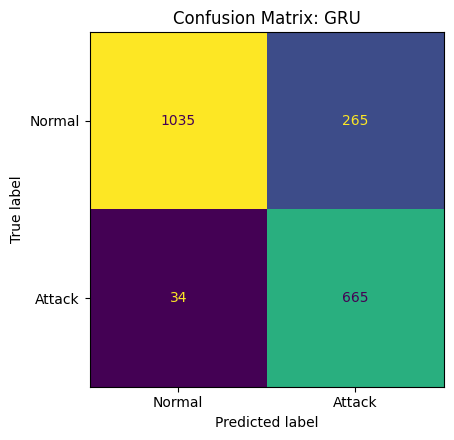

Training LSTM


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 30, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          29,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,553 (123.25 KB)

 Trainable params: 31,553 (123.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7178 - auc: 0.7638 - loss: 0.5451 - precision: 0.5807 - recall: 0.6530 - val_accuracy: 0.8550 - val_auc: 0.9532 - val_loss: 0.2559 - val_precision: 0.7228 - val_recall: 0.9500
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8646 - auc: 0.9563 - loss: 0.2477 - precision: 0.7438 - recall: 0.9276 - val_accuracy: 0.8575 - val_auc: 0.9557 - val_loss: 0.2264 - val_precision: 0.7495 - val_recall: 0.8905
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8718 - auc: 0.9615 - loss: 0.2312 - precision: 0.7568 - recall: 0.9263 - val_accuracy: 0.8575 - val_auc: 0.9558 - val_loss: 0.2288 - val_precision: 0.7456 - val_recall: 0.9000
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8751 - auc: 0.9634 - loss: 0.2304 - precision: 0.7684 - recall: 0.9136 - val_accuracy: 0.8608 - val_auc: 0.9586 - val_loss: 0.2210 - val_precision: 0.7313 - val_recall: 0.9524
Epoch 5/15
107/107 ━━━━━━━━━━━

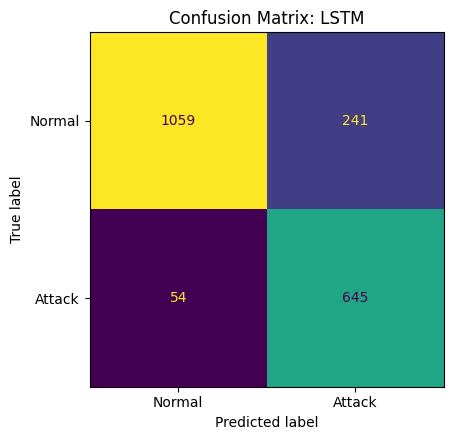

Training CNN-GRU


Model: "CNN_GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)           │ (None, 30, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 30, 64)              │           9,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 30, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 30, 64)              │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 30, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 64)                  │          24,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 49,601 (193.75 KB)

 Trainable params: 49,345 (192.75 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7119 - auc: 0.7473 - loss: 0.5638 - precision: 0.5757 - recall: 0.5958 - val_accuracy: 0.8542 - val_auc: 0.9450 - val_loss: 0.2675 - val_precision: 0.7495 - val_recall: 0.8762
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8570 - auc: 0.9453 - loss: 0.2827 - precision: 0.7363 - recall: 0.9130 - val_accuracy: 0.8550 - val_auc: 0.9499 - val_loss: 0.2479 - val_precision: 0.7795 - val_recall: 0.8167
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8691 - auc: 0.9552 - loss: 0.2518 - precision: 0.7471 - recall: 0.9390 - val_accuracy: 0.8542 - val_auc: 0.9534 - val_loss: 0.2318 - val_precision: 0.7515 - val_recall: 0.8714
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8748 - auc: 0.9654 - loss: 0.2206 - precision: 0.7525 - recall: 0.9497 - val_accuracy: 0.8617 - val_auc: 0.9566 - val_loss: 0.2187 - val_precision: 0.7480 - val_recall: 0.9119
Epoch 5/15
107/107 ━━━━━━━━━

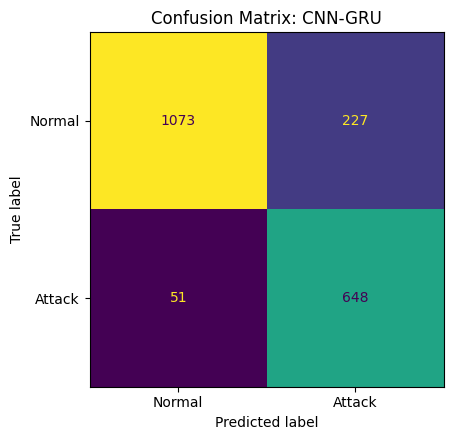

Training CNN-GRU + FFT


Model: "CNN_GRU_FFT_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ sequence_input (InputLayer)   │ (None, 30, 50)            │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 30, 64)            │           9,664 │ sequence_input[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 30, 64)            │             256 │ conv1d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fft_input (InputLayer)        │ (None, 96)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_3 (Conv1D)             │ (None, 30, 64)            │          12,352 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 64)                │           6,208 │ fft_input[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 30, 64)            │             256 │ conv1d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 64)                │             256 │ dense_6[0][0]              │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ gru_2 (GRU)                   │ (None, 64)                │          24,960 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_7 (Dropout)           │ (None, 64)                │               0 │ batch_normalization_4[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_6 (Dropout)           │ (None, 64)                │               0 │ gru_2[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 32)                │           2,080 │ dropout_7[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 96)                │               0 │ dropout_6[0][0],           │
│                               │                           │                 │ dense_7[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_8 (Dense)               │ (None, 64)                │           6,208 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_8 (Dropout)           │ (None, 64)                │               0 │ dense_8[0][0]              │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 64,353 (251.38 KB)

 Trainable params: 63,969 (249.88 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6224 - auc: 0.7108 - loss: 0.6007 - precision: 0.4896 - recall: 0.7417 - val_accuracy: 0.8433 - val_auc: 0.9345 - val_loss: 0.3056 - val_precision: 0.7544 - val_recall: 0.8190
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8517 - auc: 0.9452 - loss: 0.2811 - precision: 0.7164 - recall: 0.9442 - val_accuracy: 0.8667 - val_auc: 0.9547 - val_loss: 0.2369 - val_precision: 0.7519 - val_recall: 0.9238
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8631 - auc: 0.9553 - loss: 0.2489 - precision: 0.7327 - recall: 0.9501 - val_accuracy: 0.8550 - val_auc: 0.9548 - val_loss: 0.2247 - val_precision: 0.7347 - val_recall: 0.9167
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8729 - auc: 0.9649 - loss: 0.2216 - precision: 0.7501 - recall: 0.9479 - val_accuracy: 0.8567 - val_auc: 0.9608 - val_loss: 0.2137 - val_precision: 0.7375 - val_recall: 0.9167
Epoch 5/15
107/107 ━━━━━━━━━

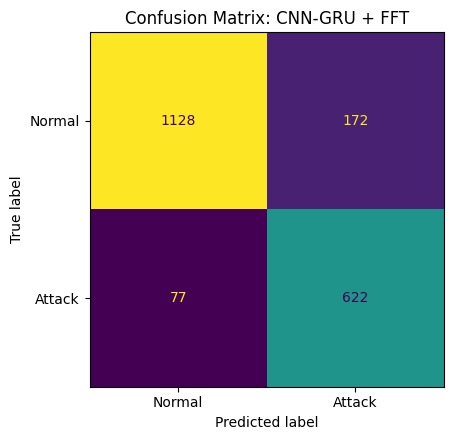

,Model,Input Type,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,GRU,Time-window sequence,0.850425,0.715054,0.951359,0.816452,0.959942
1,LSTM,Time-window sequence,0.852426,0.727991,0.922747,0.813880,0.957752
2,CNN-GRU,Time-window sequence,0.860930,0.740571,0.927039,0.823380,0.958553
3,CNN-GRU + FFT,Time-window sequence + FFT features,0.875438,0.783375,0.889843,0.833222,0.964143


In [17]:
# ============================================================
# Train Deep Learning Models
# ============================================================

dl_results = []
histories = {}
trained_models = {}

if HAS_TENSORFLOW:
    sequence_shape = X_train_seq.shape[1:]
    fft_shape = X_train_fft.shape[1:]

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        )
    ]

    model_builders = [
        ("GRU", lambda: build_gru_model(sequence_shape), "sequence"),
        ("LSTM", lambda: build_lstm_model(sequence_shape), "sequence"),
        ("CNN-GRU", lambda: build_cnn_gru_model(sequence_shape), "sequence"),
        ("CNN-GRU + FFT", lambda: build_cnn_gru_fft_model(sequence_shape, fft_shape), "sequence_fft"),
    ]

    for model_name, builder, input_type in model_builders:
        print("=" * 70)
        print(f"Training {model_name}")
        print("=" * 70)

        model = builder()
        model.summary()

        if input_type == "sequence":
            history = model.fit(
                X_train_seq,
                y_train_seq,
                validation_split=VALIDATION_SPLIT,
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                class_weight=class_weight,
                callbacks=callbacks,
                verbose=1,
            )
            y_score = model.predict(X_test_seq, batch_size=BATCH_SIZE).ravel()
        else:
            history = model.fit(
                [X_train_seq, X_train_fft],
                y_train_seq,
                validation_split=VALIDATION_SPLIT,
                epochs=EPOCHS,
                batch_size=BATCH_SIZE,
                class_weight=class_weight,
                callbacks=callbacks,
                verbose=1,
            )
            y_score = model.predict([X_test_seq, X_test_fft], batch_size=BATCH_SIZE).ravel()

        y_pred = (y_score >= 0.5).astype(int)

        result = {
            "Model": model_name,
            "Input Type": "Time-window sequence" if input_type == "sequence" else "Time-window sequence + FFT features",
            "Accuracy": accuracy_score(y_test_seq, y_pred),
            "Precision": precision_score(y_test_seq, y_pred, zero_division=0),
            "Recall": recall_score(y_test_seq, y_pred, zero_division=0),
            "F1-score": f1_score(y_test_seq, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test_seq, y_score) if len(np.unique(y_test_seq)) == 2 else np.nan,
        }
        dl_results.append(result)
        histories[model_name] = history
        trained_models[model_name] = model

        print(classification_report(y_test_seq, y_pred, target_names=["Normal", "Attack"], zero_division=0))

        cm = confusion_matrix(y_test_seq, y_pred)
        fig, ax = plt.subplots(figsize=(5.5, 4.5))
        disp = ConfusionMatrixDisplay(cm, display_labels=["Normal", "Attack"])
        disp.plot(ax=ax, values_format="d", colorbar=False)
        ax.set_title(f"Confusion Matrix: {model_name}")
        plt.tight_layout()
        plt.show()

else:
    print("TensorFlow is not installed. Deep Learning training was skipped.")
    print("Install TensorFlow with: pip install tensorflow")

if len(dl_results) > 0:
    dl_results_df = pd.DataFrame(dl_results)
    display(dl_results_df)
else:
    dl_results_df = pd.DataFrame()

## 17. Training Curves

This section visualizes how the Deep Learning models trained over epochs.

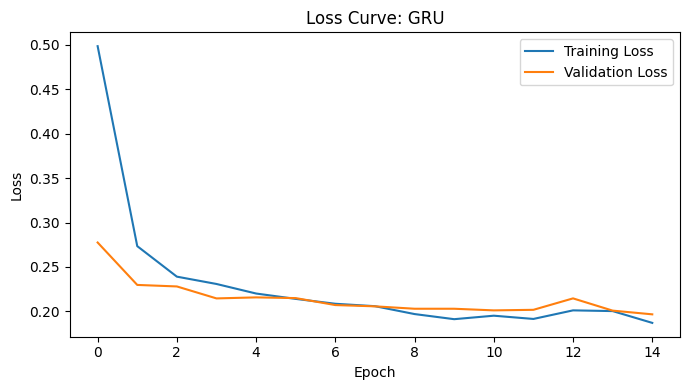

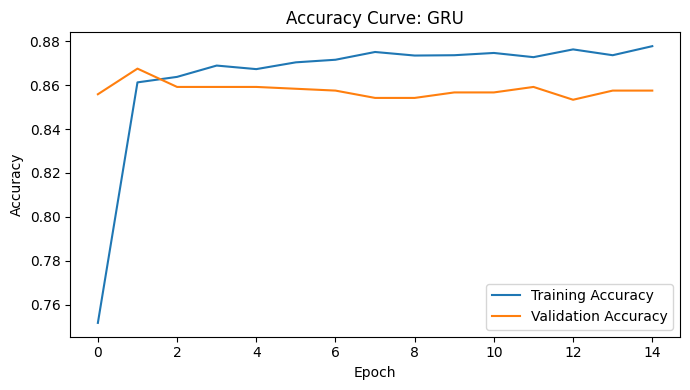

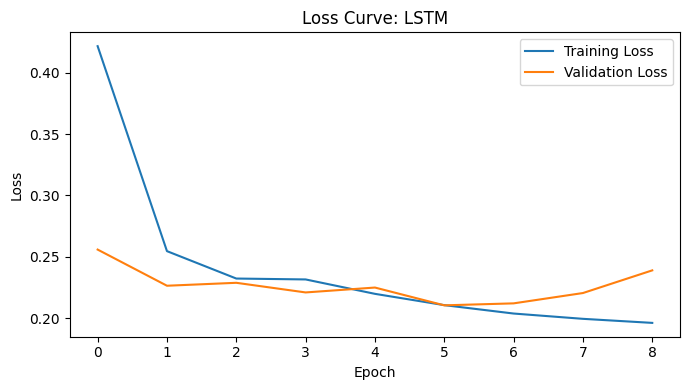

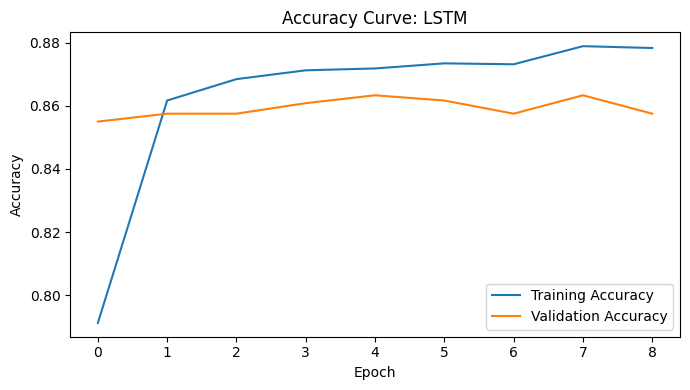

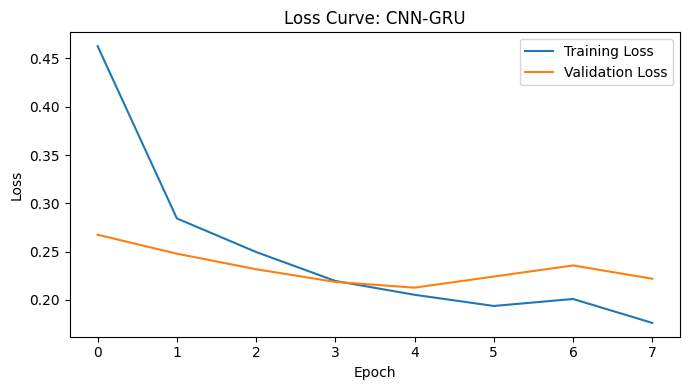

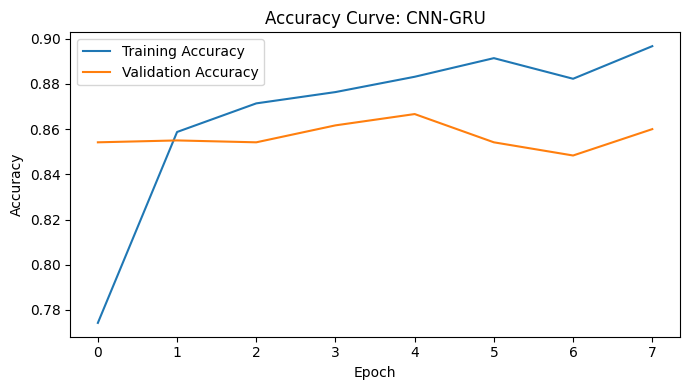

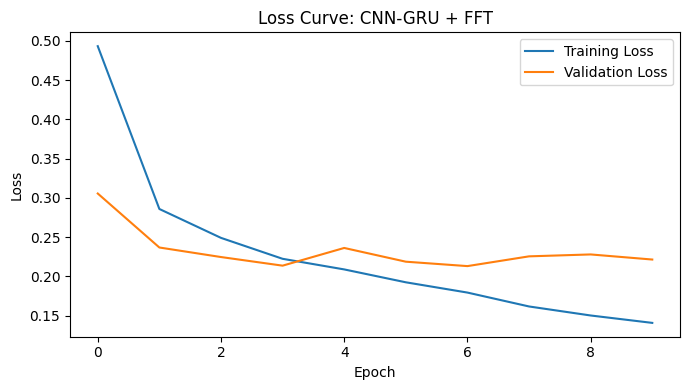

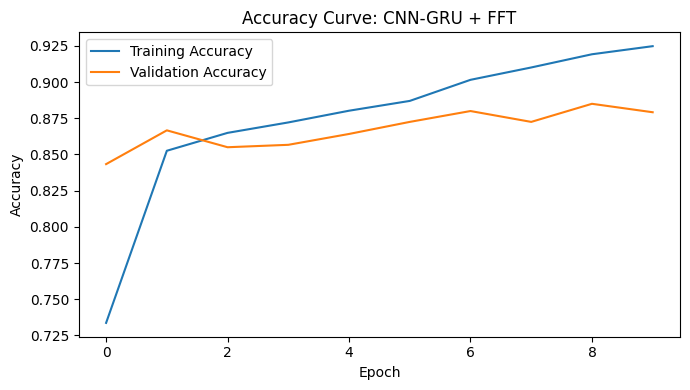

In [18]:
# ============================================================
# Training Curves
# ============================================================

if HAS_TENSORFLOW and len(histories) > 0:
    for model_name, history in histories.items():
        hist = history.history

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(hist.get("loss", []), label="Training Loss")
        ax.plot(hist.get("val_loss", []), label="Validation Loss")
        ax.set_title(f"Loss Curve: {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        plt.tight_layout()
        plt.show()

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(hist.get("accuracy", []), label="Training Accuracy")
        ax.plot(hist.get("val_accuracy", []), label="Validation Accuracy")
        ax.set_title(f"Accuracy Curve: {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No Deep Learning histories available to plot.")

## 18. Final Model Comparison

This combines baseline ML and Deep Learning results into one comparison table.

,Model,Input Type,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Random Forest,Row-level NetFlow features,0.992650,0.995518,0.947266,0.970793,0.996445
0,Logistic Regression,Row-level NetFlow features,0.974850,0.936869,0.863125,0.898486,0.969023
5,CNN-GRU + FFT,Time-window sequence + FFT features,0.875438,0.783375,0.889843,0.833222,0.964143
4,CNN-GRU,Time-window sequence,0.860930,0.740571,0.927039,0.823380,0.958553
2,GRU,Time-window sequence,0.850425,0.715054,0.951359,0.816452,0.959942
3,LSTM,Time-window sequence,0.852426,0.727991,0.922747,0.813880,0.957752


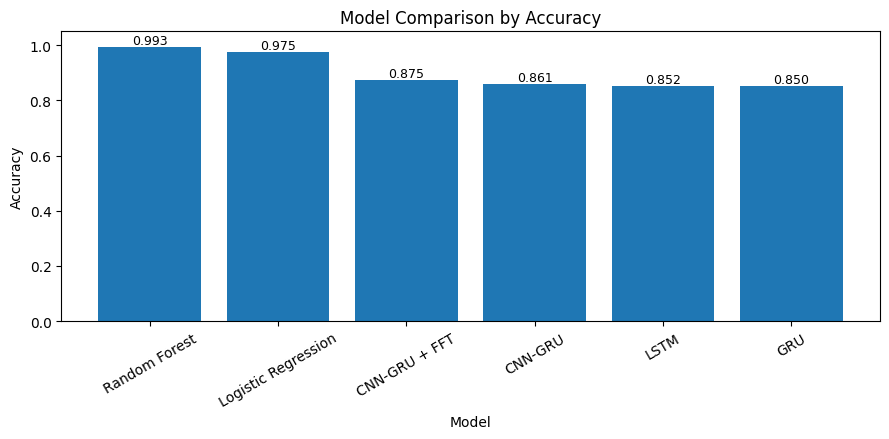

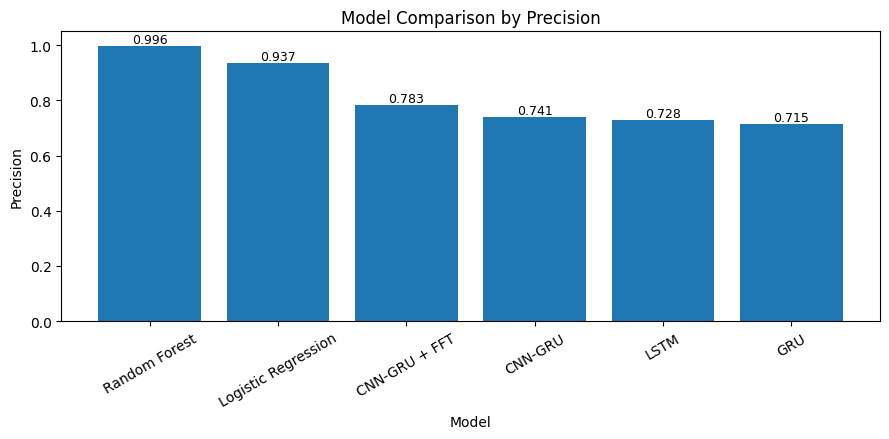

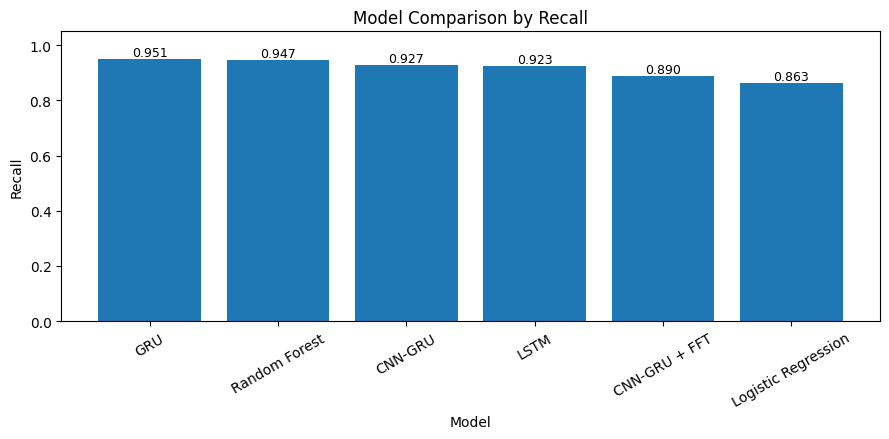

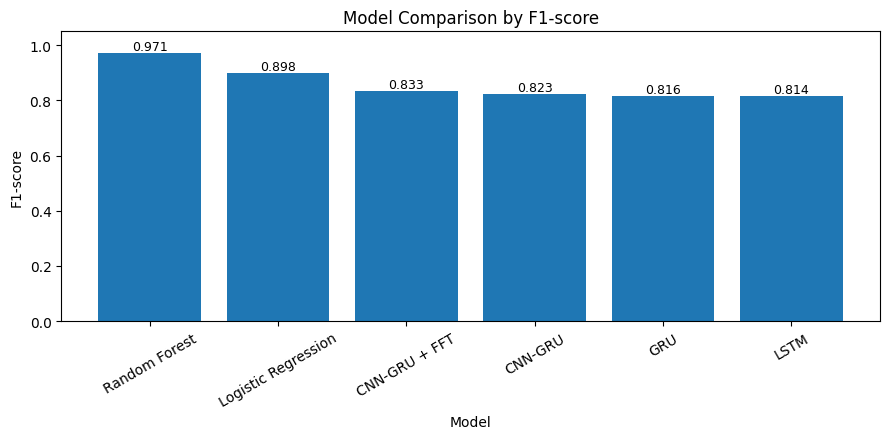

In [19]:
# ============================================================
# Final Model Comparison
# ============================================================

comparison_frames = []

if "baseline_results_df" in globals() and len(baseline_results_df) > 0:
    comparison_frames.append(baseline_results_df)

if "dl_results_df" in globals() and len(dl_results_df) > 0:
    comparison_frames.append(dl_results_df)

if len(comparison_frames) > 0:
    final_results_df = pd.concat(comparison_frames, ignore_index=True)
    metric_cols = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
    for col in metric_cols:
        if col in final_results_df.columns:
            final_results_df[col] = final_results_df[col].astype(float)

    display(final_results_df.sort_values("F1-score", ascending=False))

    # Bar chart for selected metrics.
    metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]
    for metric in metrics_to_plot:
        fig, ax = plt.subplots(figsize=(9, 4.5))
        plot_df = final_results_df.sort_values(metric, ascending=False)
        ax.bar(plot_df["Model"], plot_df[metric])
        ax.set_title(f"Model Comparison by {metric}")
        ax.set_xlabel("Model")
        ax.set_ylabel(metric)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=30)
        for i, v in enumerate(plot_df[metric]):
            ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
        plt.tight_layout()
        plt.show()
else:
    print("No model results available yet.")

## 19. Discussion Guide

Use the generated results to complete the written discussion.

### Main interpretation points

1. **Baseline ML performance** shows how well row-level NetFlow classification works.
2. **GRU and LSTM performance** shows whether traffic sequences add useful temporal information.
3. **CNN-GRU performance** shows whether local traffic patterns and temporal behavior work better together.
4. **CNN-GRU + FFT performance** shows whether frequency-domain traffic behavior adds value.

### Important limitation

If no timestamp column was available, write this honestly:

> Since the dataset did not contain an explicit timestamp column, time-window construction was based on dataset row order. This allowed sequential modeling for experimental purposes, but it may not fully represent real chronological network behavior.

### Recommended project claim

> SentinelFlow demonstrates a Deep Learning-based approach for intrusion detection by transforming NetFlow records into time-windowed traffic sequences and enhancing selected windows with FFT-based frequency-domain features.

In [20]:
# ============================================================
# Automatic Discussion Summary
# ============================================================

print("SentinelFlow Discussion Summary")
print("=" * 60)

print(f"Dataset used: {DATA_PATH}")
print(f"Working sample size: {len(df_clean):,} rows")
print(f"Feature count used: {len(feature_cols):,}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Window stride: {WINDOW_STRIDE}")
print(f"Window label mode: {WINDOW_LABEL_MODE}")
print(f"Timestamp column used: {TIMESTAMP_COL if TIMESTAMP_COL is not None else 'None'}")

if "final_results_df" in globals() and len(final_results_df) > 0:
    best_model = final_results_df.sort_values("F1-score", ascending=False).iloc[0]
    print("\nBest model based on F1-score:")
    print(best_model.to_string())
else:
    print("\nNo model comparison available yet.")

print("\nSuggested limitation statement:")
if TIMESTAMP_COL is None:
    print("Since the dataset did not contain an explicit timestamp column, time-window construction was based on dataset row order. This allowed sequential modeling for experimental purposes, but it may not fully represent real chronological network behavior.")
else:
    print(f"Rows were sorted using the detected timestamp-like column {TIMESTAMP_COL}. However, this remains an offline experimental pipeline and should not yet be treated as a real-time deployment system.")

SentinelFlow Discussion Summary
Dataset used: data\raw\NetFlow_v3_Features.csv
Working sample size: 299,853 rows
Feature count used: 50
Window size: 30
Window stride: 30
Window label mode: any_attack
Timestamp column used: FLOW_START_MILLISECONDS

Best model based on F1-score:
Model                      Random Forest
Input Type    Row-level NetFlow features
Accuracy                         0.99265
Precision                       0.995518
Recall                          0.947266
F1-score                        0.970793
ROC-AUC                         0.996445

Suggested limitation statement:
Rows were sorted using the detected timestamp-like column FLOW_START_MILLISECONDS. However, this remains an offline experimental pipeline and should not yet be treated as a real-time deployment system.


## Corrected Results Analysis After Leakage Removal

After the initial one-class and leakage issues were addressed, the experiment was rerun using `Attack` as the target column while excluding direct label-related fields from the input feature matrix. The excluded non-feature columns include `Attack`, `Label`, `FLOW_START_MILLISECONDS`, `__parsed_timestamp__`, and `binary_label`. This correction is important because the previous near-perfect results were likely inflated by direct target leakage, especially from the numeric `Label` column.

With leakage removed, the feature matrix contains 50 numerical NetFlow features and the results are more realistic. The `Random Forest` model achieved the best overall performance, with accuracy of 0.992650, precision of 0.995518, recall of 0.947266, F1-score of 0.970793, and ROC-AUC of 0.996445. This indicates that row-level NetFlow features contain strong discriminative information for distinguishing normal and attack traffic.

The `Logistic Regression` baseline also performed well, but its lower recall of 0.863125 and F1-score of 0.898486 show that a linear classifier misses more attack cases than Random Forest. This suggests that the relationship between NetFlow features and attack behavior is not purely linear.

Among the deep learning models, `CNN-GRU + FFT` was the strongest, reaching accuracy of 0.875438, precision of 0.783375, recall of 0.889843, F1-score of 0.833222, and ROC-AUC of 0.964143. Its improvement over plain `CNN-GRU` suggests that FFT-derived frequency-domain information adds useful signal to the time-windowed representation. However, the deep learning models did not outperform the Random Forest baseline in this experiment.

The main conclusion is that, after leakage removal, traditional row-level machine learning, especially Random Forest, produced the strongest overall results on this sampled NetFlow setup. The deep learning pipeline remains valuable because it demonstrates time-windowed and FFT-enhanced intrusion detection, but the current evidence supports Random Forest as the best-performing model for this version of the dataset and preprocessing pipeline.

These corrected results are more defensible than the earlier perfect scores. They should be reported as the final experimental results, with the limitation that this remains an offline sampled experiment and should be validated further using a separate holdout file or deployment-like traffic stream before claiming real-world performance.

## 20. Future Django Application Direction

After this notebook is stable, the next phase can become a Django web application.

Suggested Django app flow:

1. User uploads a NetFlow CSV file.
2. The app applies the same preprocessing pipeline.
3. The app creates time-windowed traffic sequences.
4. The trained model predicts normal or suspicious traffic windows.
5. The dashboard displays risk score, detected attack windows, confusion-style summary, and traffic feature visualizations.

For now, this notebook is the correct first stage. It validates the dataset and the Deep Learning pipeline before building the application.

## Acronym Glossary

| Acronym | Meaning |
|---|---|
| CNN | Convolutional Neural Network |
| CSV | Comma-Separated Values |
| DL | Deep Learning |
| EDA | Exploratory Data Analysis |
| FFT | Fast Fourier Transform |
| GRU | Gated Recurrent Unit |
| LSTM | Long Short-Term Memory |
| ML | Machine Learning |
| NIDS | Network Intrusion Detection System |
| RAM | Random Access Memory |
| ROC-AUC | Receiver Operating Characteristic Area Under the Curve |